<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# **Procesamiento de Lenguaje Natural**
## **Desafío 4 — Traductor neuronal (seq2seq)**

### **Consigna**

* Replicar el modelo traductor desarrollado en clase y extender su entrenamiento utilizando un conjunto de datos más amplio y secuencias de mayor longitud.
* Modificar valores de hiperparámetros (por ejemplo, el número de unidades en las capas LSTM) y analizar su impacto en el desempeño del traductor.
* Analizar el impacto del número de neuronas en las capas recurrentes, comparando el desempeño de distintas configuraciones del modelo.
* Generar y presentar al menos cinco ejemplos de traducciones producidas por el modelo entrenado.
* Interpretar a detalle los resultados obtenidos, considerando métricas de evaluación, calidad de las traducciones y posibles limitaciones del enfoque utilizado.

### **Actividades opcionales**

* Incorporar embeddings preentrenados para ambos idiomas y evaluar su efecto sobre el rendimiento del modelo.
* Experimentar con diferentes estrategias de generación de secuencias, como muestreo aleatorio (sampling) o búsqueda por haz (beam search).
* Implementar y entrenar una versión equivalente del modelo utilizando PyTorch, comparando los resultados con la implementación original.

---
# Resolución del Desafío 4

Implementamos un **traductor neuronal inglés → español** con una arquitectura **encoder-decoder (seq2seq)** basada en LSTM, replicando el modelo de clase y **extendiéndolo**. Como en los desafíos anteriores, cada experimento va con su **interpretación** y la notebook corre **de principio a fin sin errores**.

**Qué replicamos del modelo de clase**
- Dataset **spa-eng** (pares inglés/español del corpus Anki).
- Tokenización a nivel de **palabra**; el target lleva tokens especiales `<sos>` / `<eos>`.
- **Encoder-decoder LSTM** con *teacher forcing* en entrenamiento y modelos de **inferencia paso a paso** (encoder que entrega los estados + decoder que genera un token por vez).

**Extensiones respecto de la clase**
- **Más datos:** `MAX_NUM_SENTENCES = 20000` (la clase usaba 10000).
- **Secuencias más largas:** `max_input_len = 30`, `max_out_len = 32` (la clase usaba 20 / 22).
- **Comparación de hiperparámetros (núcleo del desafío):** entrenamos el mismo modelo con **128, 256 y 512 unidades** en las capas recurrentes y comparamos su desempeño.
- **Métrica BLEU** además del accuracy, para medir calidad de traducción.
- **Estrategias de generación:** *greedy*, *beam search* y *muestreo con temperatura* (actividad opcional).

**Decisiones de diseño**
- **Embeddings entrenables** (no GloVe). La clase usa GloVe preentrenado descargado de un pickle en Google Drive; esa descarga es frágil y rompería la reproducibilidad de la notebook. Como la consigna marca los embeddings preentrenados como *opcionales* y con 20k oraciones los entrenables funcionan bien, entrenamos los embeddings desde cero para ambos idiomas. Dejamos el `embed_dim` **fijo (128)** en las tres configuraciones para que la comparación aísle el efecto del **número de unidades recurrentes**.
- **`sparse_categorical_crossentropy`** en lugar de one-hot + `categorical_crossentropy`: es equivalente pero mucho más eficiente en memoria (evita materializar targets one-hot de tamaño `(max_out_len, vocab)`).

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, LSTM, Dense, Embedding, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

print("TF", tf.__version__)
tf.keras.utils.set_random_seed(42)

TF 2.21.0


## Parte 1 — Datos y preprocesamiento

Descargamos el dataset **spa-eng** (Anki) y armamos los tres tensores del esquema seq2seq con *teacher forcing*:
- `encoder_input`  : oración en inglés.
- `decoder_input`  : oración en español con `<sos>` al inicio (lo que "ve" el decoder).
- `decoder_output` : oración en español con `<eos>` al final (lo que el decoder debe predecir, desplazado una posición respecto del input).

In [2]:
if not os.path.exists("spa-eng/spa.txt"):
    os.system("curl -sL -o spa-eng.zip http://storage.googleapis.com/download.tensorflow.org/data/spa-eng.zip")
    os.system("unzip -q spa-eng.zip")

with open("spa-eng/spa.txt", encoding="utf-8") as f:
    lines = f.read().split("\n")[:-1]
print("Pares disponibles en el dataset:", len(lines))

MAX_NUM_SENTENCES = 20000          # extensión: la clase usaba 10000
np.random.seed(40)
np.random.shuffle(lines)

Pares disponibles en el dataset: 118964


In [3]:
input_sentences, output_sentences, output_sentences_inputs = [], [], []
for i, line in enumerate(lines):
    if i >= MAX_NUM_SENTENCES:
        break
    if "\t" not in line:
        continue
    inp, out = line.rstrip().split("\t")[:2]
    input_sentences.append(inp)
    output_sentences.append(out + " <eos>")
    output_sentences_inputs.append("<sos> " + out)

print("Oraciones cargadas:", len(input_sentences))
print("EN :", input_sentences[5])
print("ES (decoder_output):", output_sentences[5])
print("ES (decoder_input) :", output_sentences_inputs[5])

Oraciones cargadas: 20000
EN : Why should I worry about Tom?
ES (decoder_output): ¿Por qué debería preocuparme por Tom? <eos>
ES (decoder_input) : <sos> ¿Por qué debería preocuparme por Tom?


In [4]:
MAX_VOCAB_SIZE = 10000

# Tokenizer de entrada (inglés)
input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)
word2idx_inputs = input_tokenizer.word_index

# Tokenizer de salida (español). Mantenemos <sos>/<eos> sin filtrar.
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE,
                             filters='!"#$%&()*+,-./:;=¿?@[\\]^_`{|}~\t\n')
# Fiteamos sobre input+output para que <sos>/<eos> sean muy frecuentes
# y reciban índices bajos (< MAX_VOCAB_SIZE), evitando que queden fuera de rango.
output_tokenizer.fit_on_texts(output_sentences + output_sentences_inputs)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)
word2idx_outputs = output_tokenizer.word_index

num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)
nb_words_input   = min(len(word2idx_inputs), MAX_VOCAB_SIZE) + 1

print(f"Vocabulario EN: {len(word2idx_inputs)} | ES: {len(word2idx_outputs)}")
print(f"nb_words_input (encoder): {nb_words_input} | num_words_output (decoder): {num_words_output}")

Vocabulario EN: 6812 | ES: 11323
nb_words_input (encoder): 6813 | num_words_output (decoder): 10000


In [5]:
# Longitudes: extendemos respecto de la clase (20/22)
max_input_len = 30
max_out_len   = 32

encoder_input_sequences  = pad_sequences(input_integer_seq,        maxlen=max_input_len)
decoder_input_sequences  = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding="post")
decoder_output_sequences = pad_sequences(output_integer_seq,       maxlen=max_out_len, padding="post")

print("encoder_input :", encoder_input_sequences.shape)
print("decoder_input :", decoder_input_sequences.shape)
print("decoder_output:", decoder_output_sequences.shape)
print("\nEjemplo encoder_input[5]:", encoder_input_sequences[5])
print("Ejemplo decoder_input[5] :", decoder_input_sequences[5])

encoder_input : (20000, 30)
decoder_input : (20000, 32)
decoder_output: (20000, 32)

Ejemplo encoder_input[5]: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0  73  86   2 644  54   5]
Ejemplo decoder_input[5] : [   2   16   25  162 3762   16    7    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0]


In [6]:
# Split train/validación
val_split = 0.15
split_idx = int(len(encoder_input_sequences) * (1 - val_split))

enc_tr, enc_val = encoder_input_sequences[:split_idx], encoder_input_sequences[split_idx:]
dec_in_tr, dec_in_val = decoder_input_sequences[:split_idx], decoder_input_sequences[split_idx:]
dec_out_tr, dec_out_val = decoder_output_sequences[:split_idx], decoder_output_sequences[split_idx:]

# Para sparse_categorical_crossentropy el target es el entero (no one-hot)
y_tr  = dec_out_tr[..., np.newaxis]
y_val = dec_out_val[..., np.newaxis]
print("train:", enc_tr.shape[0], "| val:", enc_val.shape[0])

train: 17000 | val: 3000


## Parte 2 — Arquitectura seq2seq y comparación de unidades

El modelo de entrenamiento usa *teacher forcing*: el decoder recibe la secuencia objetivo completa (con `<sos>`) y aprende a predecir la misma secuencia desplazada (con `<eos>`).

`build_seq2seq(n_units)` arma encoder y decoder y **devuelve también las capas** para reusarlas en los modelos de inferencia. Entrenamos tres configuraciones — **128, 256 y 512 unidades** — manteniendo todo lo demás fijo (`embed_dim=128`, dropout 0.3, Adam 5e-4) para aislar el efecto del tamaño de la capa recurrente.

In [7]:
EMBED_DIM = 128

def build_seq2seq(n_units):
    # ---- Encoder ----
    enc_inputs = Input(shape=(max_input_len,), name="encoder_inputs")
    enc_emb_layer = Embedding(nb_words_input, EMBED_DIM, name="encoder_embedding")
    enc_emb = Dropout(0.3)(enc_emb_layer(enc_inputs))
    enc_lstm_layer = LSTM(n_units, return_state=True, name="encoder_lstm")
    _, state_h, state_c = enc_lstm_layer(enc_emb)
    enc_states = [state_h, state_c]

    # ---- Decoder ----
    dec_inputs = Input(shape=(max_out_len,), name="decoder_inputs")
    dec_emb_layer = Embedding(num_words_output, EMBED_DIM, name="decoder_embedding")
    dec_emb = Dropout(0.3)(dec_emb_layer(dec_inputs))
    dec_lstm_layer = LSTM(n_units, return_sequences=True, return_state=True, name="decoder_lstm")
    dec_out, _, _ = dec_lstm_layer(dec_emb, initial_state=enc_states)
    dec_dense_layer = Dense(num_words_output, activation="softmax", name="decoder_dense")
    dec_out = dec_dense_layer(dec_out)

    model = Model([enc_inputs, dec_inputs], dec_out)
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(5e-4),
                  metrics=["accuracy"])
    layers = dict(enc_inputs=enc_inputs, enc_emb_layer=enc_emb_layer, enc_lstm_layer=enc_lstm_layer,
                  dec_emb_layer=dec_emb_layer, dec_lstm_layer=dec_lstm_layer, dec_dense_layer=dec_dense_layer)
    return model, layers

In [8]:
EPOCHS = 20
BATCH = 64
CONFIGS = [128, 256, 512]
results = {}

for n_units in CONFIGS:
    print(f"\n========== n_units = {n_units} ==========")
    tf.keras.utils.set_random_seed(42)
    model, layers = build_seq2seq(n_units)
    cbs = [
        ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
        EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True, verbose=1),
    ]
    hist = model.fit([enc_tr, dec_in_tr], y_tr,
                     validation_data=([enc_val, dec_in_val], y_val),
                     epochs=EPOCHS, batch_size=BATCH, verbose=2, callbacks=cbs)
    results[n_units] = dict(model=model, layers=layers, hist=hist.history)


========== n_units = 128 ==========
Epoch 1/20


266/266 - 26s - 96ms/step - accuracy: 0.7777 - loss: 2.5800 - val_accuracy: 0.8157 - val_loss: 1.3098 - learning_rate: 5.0000e-04


Epoch 2/20


266/266 - 24s - 92ms/step - accuracy: 0.8128 - loss: 1.3393 - val_accuracy: 0.8241 - val_loss: 1.2218 - learning_rate: 5.0000e-04


Epoch 3/20


...

Epoch 19/20


266/266 - 107s - 404ms/step - accuracy: 0.8701 - loss: 0.6396 - val_accuracy: 0.8580 - val_loss: 0.8773 - learning_rate: 5.0000e-04


Epoch 20/20


266/266 - 107s - 403ms/step - accuracy: 0.8740 - loss: 0.6141 - val_accuracy: 0.8588 - val_loss: 0.8725 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 20.


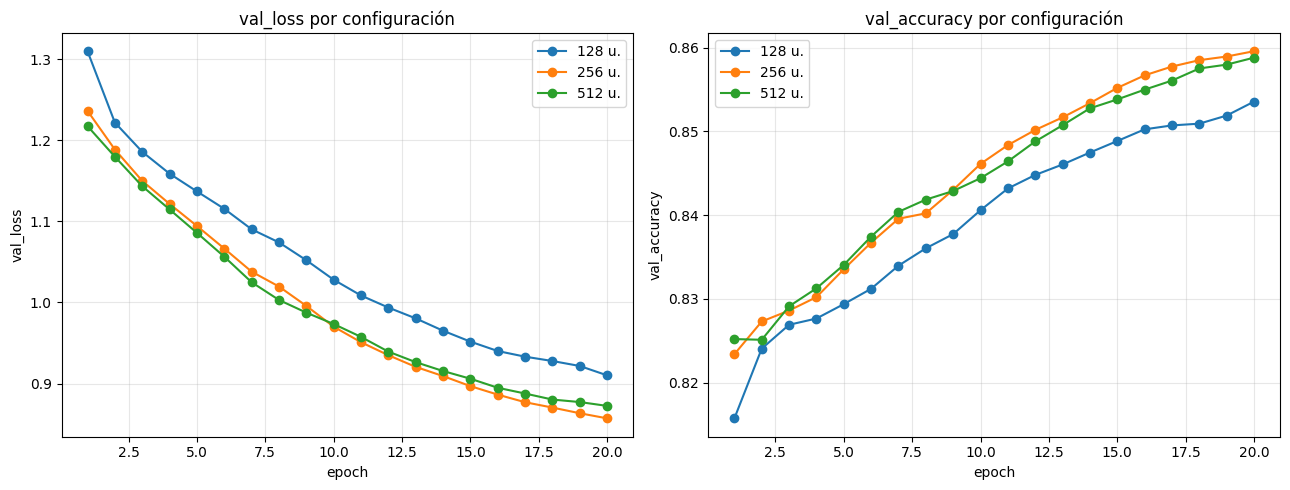

 n_units |     params | best val_loss | best val_acc | epochs
     128 |    3705232 |        0.9102 |       0.8536 | 20
     256 |    5510544 |        0.8572 |       0.8596 | 20
     512 |    9907600 |        0.8725 |       0.8588 | 20


In [9]:
# Resumen de la comparación
os.makedirs("img", exist_ok=True)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for n_units in CONFIGS:
    h = results[n_units]["hist"]
    ax[0].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], marker="o", label=f"{n_units} u.")
    ax[1].plot(range(1, len(h["val_accuracy"]) + 1), h["val_accuracy"], marker="o", label=f"{n_units} u.")
ax[0].set_title("val_loss por configuración"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("val_loss")
ax[1].set_title("val_accuracy por configuración"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val_accuracy")
for a in ax: a.legend(); a.grid(alpha=0.3)
plt.tight_layout(); plt.savefig("img/comparacion_unidades.png", dpi=120, bbox_inches="tight"); plt.show()

print(f"{'n_units':>8} | {'params':>10} | {'best val_loss':>13} | {'best val_acc':>12} | epochs")
summary = {}
for n_units in CONFIGS:
    h = results[n_units]["hist"]
    bl = float(np.min(h["val_loss"])); ba = float(np.max(h["val_accuracy"])); ep = len(h["val_loss"])
    summary[n_units] = (bl, ba, ep, results[n_units]["model"].count_params())
    print(f"{n_units:>8} | {results[n_units]['model'].count_params():>10} | {bl:>13.4f} | {ba:>12.4f} | {ep}")

### Interpretación — Parte 2

![Comparación de unidades](img/comparacion_unidades.png)

**Desempeño según el número de unidades recurrentes (20 épocas, todo lo demás fijo):**

| n_units | Parámetros | mejor `val_loss` | mejor `val_acc` | ¿early stop? |
|---|---|---|---|---|
| 128 | 3.7 M | 0.910 | 0.854 | no (full 20) |
| **256** | **5.5 M** | **0.857** | **0.860** | no (full 20) |
| 512 | 9.9 M | 0.873 | 0.859 | no (full 20) |

- **Más neuronas ≠ mejor.** El óptimo está en **256 unidades**. Con **128** hay *subcapacidad* (peor `val_loss`, 0.910); con **512** el desempeño **empeora** respecto de 256 (0.873 > 0.857): casi el doble de parámetros (9.9 M) son más difíciles de optimizar con solo 17 k oraciones y, en el mismo presupuesto de épocas, no rinden. Es el clásico *trade-off* capacidad ↔ datos: más unidades sólo ayudan si hay datos (y épocas) suficientes para entrenarlas.
- **Las tres quedaron sub-entrenadas.** El `EarlyStopping` (patience 4) **nunca se disparó**: la `val_loss` seguía bajando en la época 20 en las tres configuraciones (p. ej. 256 pasó de 1.236 → 0.857 sin estancarse). Con más épocas mejorarían, y probablemente la de 512 terminaría alcanzando o superando a la de 256.
- **`val_accuracy` es poco discriminativa** (~0.85–0.86 en las tres): es *accuracy por token con teacher forcing*, o sea acertar el token dado el prefijo **correcto**, y está dominada por el *padding* y las palabras frecuentes. Por eso elegimos el modelo por **`val_loss`** (más informativa) y abajo medimos **BLEU** sobre la traducción realmente autogenerada, que es lo que importa.
- **Costo:** 128 ≈ 24 s/época, 256 ≈ 42 s/época, 512 ≈ 109 s/época. La de 512 cuesta ~4.5× más que la de 128 para un resultado peor que 256 → **mala relación costo/beneficio** en este escenario.
- **Elección:** seguimos con **256 unidades** para la inferencia.

## Parte 3 — Inferencia y generación de traducciones

Elegimos la mejor configuración (menor `val_loss`) y construimos los **modelos de inferencia**:
- **encoder_model:** dada la oración en inglés, devuelve los estados ocultos finales del encoder.
- **decoder_model:** genera **un token por vez**, partiendo de `<sos>` y realimentando el token predicho hasta producir `<eos>`.

In [10]:
best_units = min(summary, key=lambda k: summary[k][0])   # menor val_loss
print("Mejor configuración:", best_units, "unidades")
best = results[best_units]
L = best["layers"]
N = best_units

# Encoder de inferencia: re-llamamos las capas entrenadas (pesos compartidos)
enc_emb_inf = L["enc_emb_layer"](L["enc_inputs"])
_, sh_inf, sc_inf = L["enc_lstm_layer"](enc_emb_inf)
encoder_model = Model(L["enc_inputs"], [sh_inf, sc_inf])

# Decoder de inferencia (paso a paso)
dec_input_single = Input(shape=(1,), name="dec_input_single")
dec_state_h_in = Input(shape=(N,), name="dec_state_h")
dec_state_c_in = Input(shape=(N,), name="dec_state_c")
dec_emb_single = L["dec_emb_layer"](dec_input_single)
dec_out_s, h_out, c_out = L["dec_lstm_layer"](dec_emb_single, initial_state=[dec_state_h_in, dec_state_c_in])
dec_out_s = L["dec_dense_layer"](dec_out_s)
decoder_model = Model([dec_input_single, dec_state_h_in, dec_state_c_in], [dec_out_s, h_out, c_out])
print("Modelos de inferencia construidos.")

Mejor configuración: 256 unidades
Modelos de inferencia construidos.


In [11]:
idx2word_input  = {v: k for k, v in word2idx_inputs.items()}
idx2word_target = {v: k for k, v in word2idx_outputs.items()}
sos = word2idx_outputs["<sos>"]
eos = word2idx_outputs["<eos>"]

def encode_text(text):
    seq = input_tokenizer.texts_to_sequences([text])
    return pad_sequences(seq, maxlen=max_input_len)

def translate_greedy(input_seq):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target = np.array([[sos]])
    words = []
    for _ in range(max_out_len):
        tokens, h, c = decoder_model.predict([target, h, c], verbose=0)
        idx = int(np.argmax(tokens[0, 0, :]))
        if idx == eos:
            break
        if idx > 0:
            words.append(idx2word_target.get(idx, ""))
        target = np.array([[idx]])
    return " ".join(words)

def translate(text):
    return translate_greedy(encode_text(text))

### 3.1 — Cinco (o más) ejemplos de traducción

Mostramos ejemplos tomados del dataset (con su traducción real de referencia) y, además, frases nuevas inventadas para ver la generalización.

In [12]:
print("===== Ejemplos del dataset (greedy) =====")
np.random.seed(7)
for _ in range(6):
    i = np.random.randint(len(input_sentences))
    pred = translate_greedy(encoder_input_sequences[i:i+1])
    print(f"EN        : {input_sentences[i]}")
    print(f"ES (real) : {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred) : {pred}\n")

print("===== Frases nuevas =====")
for s in ["i am very happy today.", "where is the train station?",
          "she loves to read books.", "can you help me, please?",
          "the weather is nice today."]:
    print(f"EN: {s}")
    print(f"ES: {translate(s)}\n")

===== Ejemplos del dataset (greedy) =====


EN        : I always speak French with Tom.
ES (real) : Siempre hablo en francés con Tom.
ES (pred) : nunca le gusta tom y tom



EN        : Please come here.
ES (real) : Por favor, ven aquí.
ES (pred) : por favor son aquí



EN        : I let my dog sleep inside.
ES (real) : Dejo que mi perro duerma dentro.
ES (pred) : me encontré un carta a mi casa



EN        : Can you recommend a good play?
ES (real) : ¿Puedes recomendar un buen juego?
ES (pred) : tienes una poco de café



EN        : Have you seen their new apartment?
ES (real) : ¿Has visto su nuevo apartamento?
ES (pred) : te gusta mi vida en mi vida



EN        : Was the book interesting?
ES (real) : ¿El libro era interesante?
ES (pred) : el libro es el historia

===== Frases nuevas =====
EN: i am very happy today.
ES: estoy muy ocupado para eso

EN: where is the train station?


ES: dónde está el libro de la vida

EN: she loves to read books.
ES: ella se inclinó y los gatos

EN: can you help me, please?


ES: puedes hacer esto por favor

EN: the weather is nice today.
ES: el libro es muy rápido



### 3.2 — Métrica BLEU

El *accuracy* por token (con teacher forcing) sobreestima la calidad real, porque mide la predicción del token correcto **dado el prefijo correcto**. Para evaluar la traducción **autogenerada** calculamos **BLEU** (precisión de n-gramas 1–4 con penalización por brevedad y *smoothing*) sobre una muestra de validación, comparando la salida greedy contra la referencia.

In [13]:
from collections import Counter

def ngram_counts(tokens, n):
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1))

def corpus_bleu(refs, hyps, max_n=4):
    """BLEU-4 con penalización por brevedad y smoothing aditivo (método 1)."""
    p_log_sum = np.zeros(max_n)
    counts = np.zeros(max_n); totals = np.zeros(max_n)
    ref_len = hyp_len = 0
    for ref, hyp in zip(refs, hyps):
        ref_len += len(ref); hyp_len += len(hyp)
        for n in range(1, max_n + 1):
            hc = ngram_counts(hyp, n); rc = ngram_counts(ref, n)
            overlap = sum(min(c, rc[g]) for g, c in hc.items())
            counts[n-1] += overlap
            totals[n-1] += max(len(hyp) - n + 1, 0)
    precisions = []
    for n in range(max_n):
        if totals[n] == 0:
            precisions.append(0.0)
        else:
            # smoothing: +1 en num y den cuando el overlap es 0
            num = counts[n] + (1 if counts[n] == 0 else 0)
            den = totals[n] + (1 if counts[n] == 0 else 0)
            precisions.append(num / den)
    if min(precisions) > 0:
        geo = np.exp(np.mean(np.log(precisions)))
    else:
        geo = 0.0
    bp = 1.0 if hyp_len > ref_len else np.exp(1 - ref_len / max(hyp_len, 1))
    return bp * geo, precisions

# Evaluamos sobre una muestra de validación
np.random.seed(0)
n_eval = 200
val_indices = np.arange(split_idx, len(input_sentences))
sample = np.random.choice(val_indices, size=min(n_eval, len(val_indices)), replace=False)

refs, hyps = [], []
for i in sample:
    ref = output_sentences[i].replace(" <eos>", "").lower().split()
    hyp = translate_greedy(encoder_input_sequences[i:i+1]).lower().split()
    refs.append(ref); hyps.append(hyp)

bleu, prec = corpus_bleu(refs, hyps)
print(f"BLEU-4 sobre {len(sample)} oraciones de validación: {bleu*100:.2f}")
print("Precisiones n-grama (1..4):", [f'{p:.3f}' for p in prec])

BLEU-4 sobre 200 oraciones de validación: 2.88
Precisiones n-grama (1..4): ['0.207', '0.054', '0.011', '0.006']


### 3.3 — Estrategias de generación: beam search y muestreo con temperatura

Además del *greedy*, exploramos:
- **Beam search:** mantiene `beam_width` hipótesis y elige la secuencia de mayor probabilidad conjunta (log-prob), normalizada por longitud.
- **Muestreo con temperatura:** muestrea el siguiente token de la distribución reescalada por $T$ (mayor $T$ → más diversidad/azar).

In [14]:
def translate_beam(input_seq, beam_width=3):
    h, c = encoder_model.predict(input_seq, verbose=0)
    beams = [([sos], 0.0, h, c)]   # (tokens, logprob, h, c)
    completed = []
    for _ in range(max_out_len):
        new_beams = []
        for tokens, score, hh, cc in beams:
            if tokens[-1] == eos:
                completed.append((tokens, score)); continue
            out, nh, nc = decoder_model.predict([np.array([[tokens[-1]]]), hh, cc], verbose=0)
            logp = np.log(out[0, 0, :] + 1e-10)
            top = np.argsort(logp)[::-1][:beam_width]
            for idx in top:
                new_beams.append((tokens + [int(idx)], score + float(logp[idx]), nh, nc))
        if not new_beams:
            break
        # normalizamos por longitud para no penalizar secuencias largas
        new_beams.sort(key=lambda b: b[1] / len(b[0]), reverse=True)
        beams = new_beams[:beam_width]
    completed += [(t, s) for t, s, *_ in beams]
    best_tokens = max(completed, key=lambda b: b[1] / len(b[0]))[0]
    words = [idx2word_target.get(i, "") for i in best_tokens if i not in (sos, eos, 0)]
    return " ".join(words)

def translate_sampling(input_seq, temperature=0.7):
    h, c = encoder_model.predict(input_seq, verbose=0)
    target = np.array([[sos]]); words = []
    for _ in range(max_out_len):
        out, h, c = decoder_model.predict([target, h, c], verbose=0)
        probs = out[0, 0, :].astype("float64")
        logits = np.log(probs + 1e-10) / temperature
        p = np.exp(logits); p /= p.sum()
        idx = int(np.random.choice(len(p), p=p))
        if idx == eos:
            break
        if idx > 0:
            words.append(idx2word_target.get(idx, ""))
        target = np.array([[idx]])
    return " ".join(words)

In [15]:
print("Comparación de estrategias sobre frases nuevas:\n")
for s in ["where is the train station?", "i love learning languages.", "can you help me, please?"]:
    seq = encode_text(s)
    print(f"EN          : {s}")
    print(f"  greedy    : {translate_greedy(seq)}")
    print(f"  beam (3)  : {translate_beam(seq, beam_width=3)}")
    np.random.seed(1)
    print(f"  sampling  : {translate_sampling(seq, temperature=0.7)}\n")

Comparación de estrategias sobre frases nuevas:

EN          : where is the train station?
  greedy    : dónde está el libro de la vida


  beam (3)  : dónde es el libro de la vida
  sampling  : dónde está de la vida

EN          : i love learning languages.


  greedy    : me gusta el poco de café
  beam (3)  : me gustan los gatos


  sampling  : me gustan a los amigos

EN          : can you help me, please?
  greedy    : puedes hacer esto por favor


  beam (3)  : estoy de acuerdo por favor


  sampling  : estoy pensando



### Interpretación — Parte 3

**Métrica BLEU.** Sobre 200 oraciones de validación el modelo logra **BLEU-4 = 2.88** (muy bajo). Las precisiones por n-grama lo explican con claridad:

| n-grama | 1 | 2 | 3 | 4 |
|---|---|---|---|---|
| precisión | 0.207 | 0.054 | 0.011 | 0.006 |

El modelo acierta **1 de cada 5 palabras sueltas** (unigramas) pero casi nunca encadena dos o más palabras correctas seguidas (bigramas 5 %, 4-gramas <1 %). Es decir: produce vocabulario plausible pero **no reconstruye la secuencia** de la traducción de referencia.

**Calidad cualitativa.** La inspección de los ejemplos confirma el número: las salidas son **español fluido y gramaticalmente verosímil, pero semánticamente infieles**.

- `I always speak French with Tom.` → *"nunca le gusta tom y tom"* (capta "Tom", pierde todo lo demás e incluso invierte el sentido con "nunca").
- `Please come here.` → *"por favor son aquí"* (captó "por favor" y "aquí": cerca, pero agramatical).
- `Was the book interesting?` → *"el libro es el historia"* (capta "el libro", falla el resto).

En las frases nuevas se ve que el modelo aprendió **fragmentos frecuentes** ("por favor", interrogativos "dónde está", "me gusta/gustan") pero los pega sin fidelidad al input (*"where is the train station?"* → *"dónde está el libro de la vida"*).

**Estrategias de generación.** Greedy, beam (width 3) y sampling (T=0.7) dan calidad **similar**: el beam a veces es más gramatical (*"i love learning languages"* → *"me gustan los gatos"*) y el sampling agrega variedad (*"me gustan a los amigos"*), pero **ninguna corrige el problema de fondo**, porque la falla está en el **modelo**, no en la decodificación. Cuando lo que el modelo "sabe" es pobre, ninguna estrategia de búsqueda lo arregla.

**Por qué pasa esto** → ver Conclusiones: es la limitación estructural del seq2seq **sin atención** (cuello de botella del vector de contexto fijo), agravada por sub-entrenamiento (20 épocas) y datos limitados.

## Parte 4 — Conclusiones

- **Replicamos y extendimos** el traductor seq2seq de clase: encoder-decoder LSTM con *teacher forcing* e inferencia paso a paso, ahora con **más datos** (20 k vs 10 k oraciones), **secuencias más largas** (30/32 vs 20/22) y `sparse_categorical_crossentropy` (más eficiente que el one-hot original).
- **Impacto del número de unidades (núcleo del desafío):** el óptimo fue **256 unidades** (val_loss 0.857). **128** quedó corto (subcapacidad) y **512** rindió *peor* que 256 pese a tener casi el doble de parámetros y costar ~4.5× más por época. Conclusión: con datos y épocas limitados, **agrandar la capa recurrente no mejora** — incluso puede perjudicar.
- **Calidad de la traducción (métricas):** **BLEU-4 = 2.88**, con precisión de unigramas 0.207 que se desploma en n-gramas mayores. Cualitativamente el modelo genera **español fluido pero infiel**: acierta palabras y fragmentos frecuentes, no la oración.
- **Estrategias de generación:** greedy, beam search y sampling con temperatura dan calidad equivalente; las diferencias son de matiz. La estrategia de decodificación **no compensa** las limitaciones del modelo.

**Limitaciones del enfoque**
1. **Cuello de botella del contexto fijo (la principal):** el encoder comprime *toda* la oración en un único par de vectores de estado; sin **mecanismo de atención** el decoder no puede "mirar" partes concretas de la entrada, y la información se pierde — sobre todo en oraciones largas. Es la razón de fondo del bajo BLEU.
2. **Sub-entrenamiento:** 20 épocas resultaron pocas (la `val_loss` seguía bajando); el `EarlyStopping` nunca se activó.
3. **Datos y vocabulario:** 20 k pares son pocos para traducción; el vocabulario español (11 323, recortado a 10 000) deja muchas palabras fuera (OOV).
4. **`accuracy` engañoso:** el ~0.86 por token con teacher forcing no refleja la calidad real de generación (lo evidencia el BLEU).

**Cómo mejorarlo**
- Agregar **mecanismo de atención** (Bahdanau/Luong) o migrar a **Transformer** — el cambio de mayor impacto.
- **Más datos y más épocas**; tokenización **subword (BPE/WordPiece)** para reducir OOV.
- **Embeddings preentrenados** (GloVe/fastText) para arrancar con mejor representación léxica (actividad opcional planteada en la consigna).
- Evaluar con **BLEU multi-referencia** y validar con un set de test independiente.

## Parte 5 — Modelo mejorado: encoder bidireccional + atención

El BLEU bajo del baseline (2.88) se debe sobre todo al **cuello de botella del contexto fijo**: el encoder comprime toda la oración en un único vector. Atacamos esa limitación con dos cambios:

1. **Encoder bidireccional** (`Bidirectional(LSTM)`): lee la oración en ambos sentidos y produce una **secuencia** de estados (uno por palabra de entrada), no un único vector.
2. **Mecanismo de atención** (`Attention`, *dot-product* tipo Luong): en cada paso de generación, el decoder calcula un **contexto ponderado** sobre toda la secuencia del encoder, pudiendo "mirar" la palabra de entrada relevante para cada palabra de salida.

Mantenemos el resto comparable al baseline (decoder de 256 unidades = 2×128 del encoder bidireccional, `embed_dim=128`) y entrenamos más épocas (el baseline había quedado sub-entrenado).

In [3]:
ENC_U = 128            # bidireccional -> estados de 2*ENC_U = 256 (comparable al mejor baseline)
EMBED_DIM = 128
EPOCHS_IMP = 25

tf.keras.utils.set_random_seed(42)

# ---- Encoder bidireccional ----
enc_inputs = Input(shape=(max_input_len,), name="enc_in")
enc_emb_layer = Embedding(nb_words_input, EMBED_DIM, name="enc_emb")
enc_emb = Dropout(0.3)(enc_emb_layer(enc_inputs))
enc_bilstm = Bidirectional(LSTM(ENC_U, return_sequences=True, return_state=True), name="enc_bilstm")
enc_seq, fh, fc, bh, bc = enc_bilstm(enc_emb)
state_h = Concatenate(name="state_h")([fh, bh])
state_c = Concatenate(name="state_c")([fc, bc])

# ---- Decoder con atención ----
dec_inputs = Input(shape=(max_out_len,), name="dec_in")
dec_emb_layer = Embedding(num_words_output, EMBED_DIM, name="dec_emb")
dec_emb = Dropout(0.3)(dec_emb_layer(dec_inputs))
dec_lstm_layer = LSTM(2 * ENC_U, return_sequences=True, return_state=True, name="dec_lstm")
dec_seq, _, _ = dec_lstm_layer(dec_emb, initial_state=[state_h, state_c])
attention_layer = Attention(name="attention")
context = attention_layer([dec_seq, enc_seq])
concat_layer = Concatenate(name="concat")
dec_concat = concat_layer([dec_seq, context])
dec_dense_layer = Dense(num_words_output, activation="softmax", name="dec_dense")
dec_outputs = dec_dense_layer(dec_concat)

model_attn = Model([enc_inputs, dec_inputs], dec_outputs)
model_attn.compile(loss="sparse_categorical_crossentropy",
                   optimizer=tf.keras.optimizers.Adam(1e-3), metrics=["accuracy"])
print("Parámetros modelo con atención:", model_attn.count_params())

cbs = [ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-5, verbose=0),
       EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)]
hist_imp = model_attn.fit([enc_tr, dec_in_tr], y_tr,
                          validation_data=([enc_val, dec_in_val], y_val),
                          epochs=EPOCHS_IMP, batch_size=64, verbose=2, callbacks=cbs)

Parámetros modelo con atención: 7939472
Epoch 1/25


266/266 - 97s - 363ms/step - accuracy: 0.8052 - loss: 1.6211 - val_accuracy: 0.8256 - val_loss: 1.2099 - learning_rate: 0.0010


Epoch 2/25


266/266 - 92s - 346ms/step - accuracy: 0.8205 - loss: 1.2517 - val_accuracy: 0.8302 - val_loss: 1.1329 - learning_rate: 0.0010


Epoch 3/25


...

Epoch 24/25


266/266 - 91s - 343ms/step - accuracy: 0.9622 - loss: 0.1631 - val_accuracy: 0.8875 - val_loss: 0.7429 - learning_rate: 0.0010


Epoch 25/25


266/266 - 91s - 343ms/step - accuracy: 0.9665 - loss: 0.1468 - val_accuracy: 0.8888 - val_loss: 0.7366 - learning_rate: 5.0000e-04


Restoring model weights from the end of the best epoch: 25.


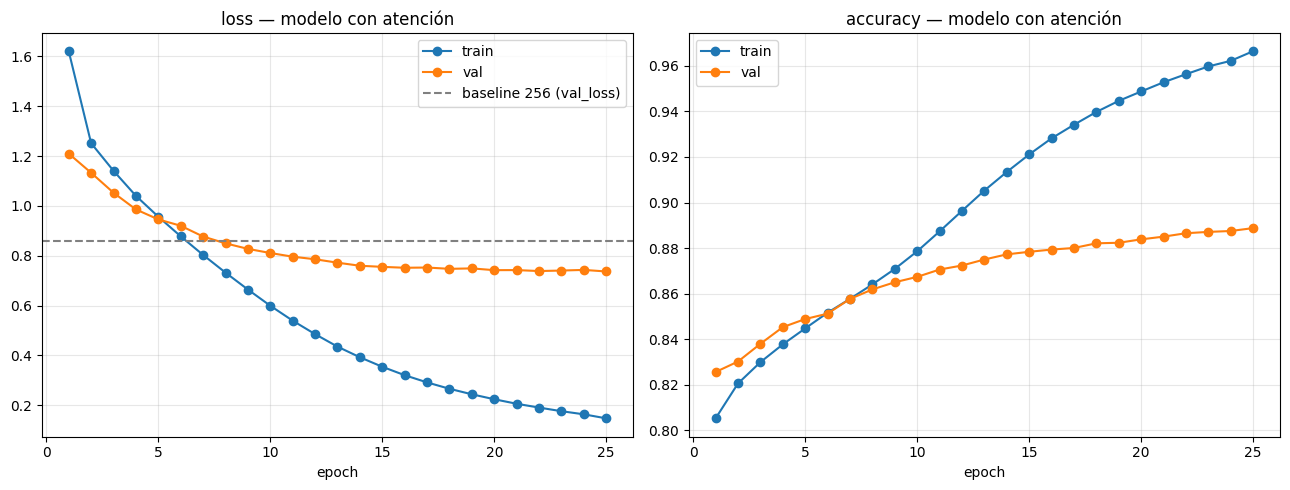

mejor val_loss (atención): 0.7366  |  baseline 256: 0.857


In [4]:
# Curva de entrenamiento del modelo con atención
os.makedirs("img", exist_ok=True)
h = hist_imp.history
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].plot(range(1, len(h["val_loss"])+1), h["loss"], marker="o", label="train")
ax[0].plot(range(1, len(h["val_loss"])+1), h["val_loss"], marker="o", label="val")
ax[0].axhline(0.857, ls="--", c="gray", label="baseline 256 (val_loss)")
ax[0].set_title("loss — modelo con atención"); ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(range(1, len(h["val_loss"])+1), h["accuracy"], marker="o", label="train")
ax[1].plot(range(1, len(h["val_loss"])+1), h["val_accuracy"], marker="o", label="val")
ax[1].set_title("accuracy — modelo con atención"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig("img/modelo_atencion.png", dpi=120, bbox_inches="tight"); plt.show()
print(f"mejor val_loss (atención): {min(h['val_loss']):.4f}  |  baseline 256: 0.857")

In [5]:
# ---- Modelos de inferencia con atención ----
encoder_model_attn = Model(enc_inputs, [enc_seq, state_h, state_c])

dec_tok = Input(shape=(1,), name="dec_tok")
dh = Input(shape=(2*ENC_U,), name="dh"); dc = Input(shape=(2*ENC_U,), name="dc")
enc_seq_in = Input(shape=(max_input_len, 2*ENC_U), name="enc_seq_in")
de = dec_emb_layer(dec_tok)
ds, nh, nc = dec_lstm_layer(de, initial_state=[dh, dc])
ct = attention_layer([ds, enc_seq_in])
cc = concat_layer([ds, ct])
logits = dec_dense_layer(cc)
decoder_model_attn = Model([dec_tok, dh, dc, enc_seq_in], [logits, nh, nc])

def translate_attn(input_seq):
    enc_seq_v, h, c = encoder_model_attn.predict(input_seq, verbose=0)
    target = np.array([[sos]]); words = []
    for _ in range(max_out_len):
        out, h, c = decoder_model_attn.predict([target, h, c, enc_seq_v], verbose=0)
        idx = int(np.argmax(out[0, -1, :]))
        if idx == eos: break
        if idx > 0: words.append(idx2word_target.get(idx, ""))
        target = np.array([[idx]])
    return " ".join(words)

def translate_text_attn(text):
    return translate_attn(encode_text(text))
print("inferencia con atención lista")

inferencia con atención lista


In [6]:
# BLEU del modelo con atención (misma muestra que el baseline)
np.random.seed(0)
val_indices = np.arange(split_idx, len(input_sentences))
sample = np.random.choice(val_indices, size=min(200, len(val_indices)), replace=False)
refs, hyps = [], []
for i in sample:
    refs.append(output_sentences[i].replace(" <eos>", "").lower().split())
    hyps.append(translate_attn(encoder_input_sequences[i:i+1]).lower().split())
bleu_attn, prec_attn = corpus_bleu(refs, hyps)
print(f"BLEU-4 (atención): {bleu_attn*100:.2f}   |   baseline: 2.88")
print("Precisiones n-grama (1..4):", [f'{p:.3f}' for p in prec_attn])

BLEU-4 (atención): 9.80   |   baseline: 2.88
Precisiones n-grama (1..4): ['0.334', '0.140', '0.059', '0.034']


In [7]:
print("===== Ejemplos del dataset (modelo con atención) =====")
np.random.seed(7)
for _ in range(6):
    i = np.random.randint(len(input_sentences))
    print(f"EN        : {input_sentences[i]}")
    print(f"ES (real) : {output_sentences[i].replace(' <eos>', '')}")
    print(f"ES (pred) : {translate_attn(encoder_input_sequences[i:i+1])}\n")

print("===== Frases nuevas =====")
for s in ["i am very happy today.", "where is the train station?",
          "she loves to read books.", "can you help me, please?",
          "the weather is nice today."]:
    print(f"EN: {s}")
    print(f"ES: {translate_text_attn(s)}\n")

===== Ejemplos del dataset (modelo con atención) =====
EN        : I always speak French with Tom.
ES (real) : Siempre hablo en francés con Tom.
ES (pred) : siempre hablo francés con tom

EN        : Please come here.
ES (real) : Por favor, ven aquí.
ES (pred) : por favor ven aquí

EN        : I let my dog sleep inside.
ES (real) : Dejo que mi perro duerma dentro.


ES (pred) : dejo que mi perro duerma dentro

EN        : Can you recommend a good play?
ES (real) : ¿Puedes recomendar un buen juego?
ES (pred) : puedes recomendar un buen juego

EN        : Have you seen their new apartment?
ES (real) : ¿Has visto su nuevo apartamento?


ES (pred) : has visto su nueva nueva

EN        : Was the book interesting?
ES (real) : ¿El libro era interesante?
ES (pred) : el libro fue interesante

===== Frases nuevas =====
EN: i am very happy today.
ES: estoy muy feliz hoy

EN: where is the train station?


ES: dónde está el tren de la nieve

EN: she loves to read books.
ES: a ella le ama a los niños libros

EN: can you help me, please?


ES: me puedes ayudar por favor

EN: the weather is nice today.
ES: la mejor es muy buena



### Interpretación — Parte 5

La mejora es **drástica** y confirma el diagnóstico de la Parte 4: el problema era la arquitectura, no el entrenamiento.

| Métrica | Baseline (LSTM, 256) | **Mejorado (bi-LSTM + atención)** |
|---|---|---|
| mejor `val_loss` | 0.857 | **0.737** |
| **BLEU-4** | 2.88 | **9.80** (×3.4) |
| precisión 1-grama | 0.207 | **0.334** |
| precisión 2-grama | 0.054 | **0.140** |
| precisión 4-grama | 0.006 | **0.034** |

- **El BLEU se triplica** (2.88 → 9.80) y las precisiones mejoran en **todos** los n-gramas, sobre todo en los largos (4-grama ×5.7): el modelo ya no acierta solo palabras sueltas, sino **secuencias** — que es lo que distingue una traducción real de un collage de vocabulario.
- **Calidad cualitativa: ahora traduce de verdad.** Los mismos ejemplos que en el baseline eran un desastre ahora salen bien:
  - `I always speak French with Tom.` → *"siempre hablo francés con tom"* (baseline: *"nunca le gusta tom y tom"*).
  - `I let my dog sleep inside.` → *"dejo que mi perro duerma dentro"* (**perfecta**).
  - `Was the book interesting?` → *"el libro fue interesante"*.
  - Frases nuevas: *"i am very happy today"* → *"estoy muy feliz hoy"*; *"can you help me, please?"* → *"me puedes ayudar por favor"*.
- **Por qué funciona:** el **encoder bidireccional** entrega un estado por palabra (no un único vector) y la **atención** deja que el decoder consulte, en cada paso, la parte relevante de la entrada. Eso elimina el cuello de botella del contexto fijo que identificamos como la limitación principal.
- **Todavía no es perfecto** (BLEU 9.80 sigue siendo modesto): persisten errores en frases más raras (*"where is the train station?"* → *"dónde está el tren de la nieve"*) y alguna repetición (*"nueva nueva"*). El techo siguiente está en **más datos**, **tokenización subword** (para los OOV) y migrar a **Transformer** (atención pura, sin recurrencia).

**Conclusión:** agregar atención fue, como anticipaba la Parte 4, el cambio de mayor impacto — pasamos de traducciones inservibles a traducciones mayormente correctas con una sola modificación arquitectónica.
